In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
df=pd.read_csv('cleanenddata.csv',index_col=0)
df.head()

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,sidi ali,6111035000430,sidi ali,0.0,20.0,42.0,14.0,0.0,0.00,0.0,0.00000,0.000000,1.0,1.0,0.0
1,jaouda,6111242100992,perly,97.0,406.0,9.4,7.5,3.0,1.15,8.0,0.00000,0.000000,3.0,4.0,0.0
2,sidi ali,6111035002175,sidi ali,0.0,20.0,42.0,14.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.0
3,les eaux minerales doulmessidi ali,6111035000058,eau minerale naturelle,0.0,0.0,0.0,0.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.0
4,aquafina,6111252421568,kwfyn,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00508,0.002032,1.0,0.0,0.0


# Feature Engineering

In [3]:

# 1️⃣ sugar_to_carb_ratio
# # Safely calculate ratio, avoid division by zero
df['sugar_to_carb_ratio'] = df.apply(
    lambda row: row['sugars_value'] / row['carbohydrates_value']
    if pd.notnull(row['sugars_value']) and pd.notnull(row['carbohydrates_value']) and row['carbohydrates_value'] != 0
    else np.nan,
    axis=1
)

# 2️⃣ calorie_category (energy-kcal_value)
# Example thresholds (per 100g)
def calorie_class(kcal):
    if pd.isnull(kcal):
        return np.nan
    elif kcal < 100:
        return 'Low'
    elif 100 <= kcal <= 250:
        return 'Moderate'
    else:
        return 'High'

df['calorie_category'] = df['energy-kcal_value'].apply(calorie_class)

# 3️⃣ sugar_category (sugars_value)
def sugar_class(sugar):
    if pd.isnull(sugar):
        return np.nan
    elif sugar < 5:
        return 'Low Sugar'
    elif 5 <= sugar <= 15:
        return 'Moderate Sugar'
    else:
        return 'High Sugar'

df['sugar_category'] = df['sugars_value'].apply(sugar_class)

# 4️⃣ is_ultra_processed (nova-group)
# Flag as 'Yes' if nova-group == 4, else 'No'
df['is_ultra_processed'] = df['nova-group'].apply(
    lambda x: 'Yes' if x == 4 else ('No' if pd.notnull(x) else np.nan)
)
df.head()

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g,sugar_to_carb_ratio,calorie_category,sugar_category,is_ultra_processed
0,sidi ali,6111035000430,sidi ali,0.0,20.0,42.0,14.0,0.0,0.00,0.0,0.00000,0.000000,1.0,1.0,0.0,0.333333,Low,Moderate Sugar,No
1,jaouda,6111242100992,perly,97.0,406.0,9.4,7.5,3.0,1.15,8.0,0.00000,0.000000,3.0,4.0,0.0,0.797872,Low,Moderate Sugar,No
2,sidi ali,6111035002175,sidi ali,0.0,20.0,42.0,14.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.0,0.333333,Low,Moderate Sugar,No
3,les eaux minerales doulmessidi ali,6111035000058,eau minerale naturelle,0.0,0.0,0.0,0.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.0,NaN,Low,Low Sugar,No
4,aquafina,6111252421568,kwfyn,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00508,0.002032,1.0,0.0,0.0,NaN,Low,Low Sugar,No


In [4]:
df.to_csv('featureeng.csv')

In [5]:
"""
Key Nutritional Indicators:
Feature--->Meaning--->Health Relevance
energy-kcal_value--->Calories per 100g--->High calories → obesity risk if consumed excessively
carbohydrates_value--->Total carbs per 100g--->Includes sugars + starches
sugars_value--->Sugar per 100g--->High sugar → diabetes, dental issues
sugar_to_carb_ratio--->Ratio of sugar to total carbs--->Higher ratio → more added sugars
fat_value, saturated-fat_value--->Total and saturated fats--->High saturated fat → heart risks
proteins_value--->Protein per 100g--->Beneficial nutrient
nova-group--->Food processing classification (1-4)--->1: Unprocessed → 4: Ultra-processed
nutrition-score-fr--->Healthiness score (lower = healthier)--->European Nutri-Score metric
calorie_category, sugar_category--->Derived labels (e.g. “Low”, “Medium”, “High”)--->Easier for grouping
is_ultra_processed--->Boolean (True if NOVA=4)--->Used to assess food processing risk
"""

'\nKey Nutritional Indicators:\nFeature--->Meaning--->Health Relevance\nenergy-kcal_value--->Calories per 100g--->High calories → obesity risk if consumed excessively\ncarbohydrates_value--->Total carbs per 100g--->Includes sugars + starches\nsugars_value--->Sugar per 100g--->High sugar → diabetes, dental issues\nsugar_to_carb_ratio--->Ratio of sugar to total carbs--->Higher ratio → more added sugars\nfat_value, saturated-fat_value--->Total and saturated fats--->High saturated fat → heart risks\nproteins_value--->Protein per 100g--->Beneficial nutrient\nnova-group--->Food processing classification (1-4)--->1: Unprocessed → 4: Ultra-processed\nnutrition-score-fr--->Healthiness score (lower = healthier)--->European Nutri-Score metric\ncalorie_category, sugar_category--->Derived labels (e.g. “Low”, “Medium”, “High”)--->Easier for grouping\nis_ultra_processed--->Boolean (True if NOVA=4)--->Used to assess food processing risk\n'

Text(0.5, 1.0, 'Correlation Heatmap')

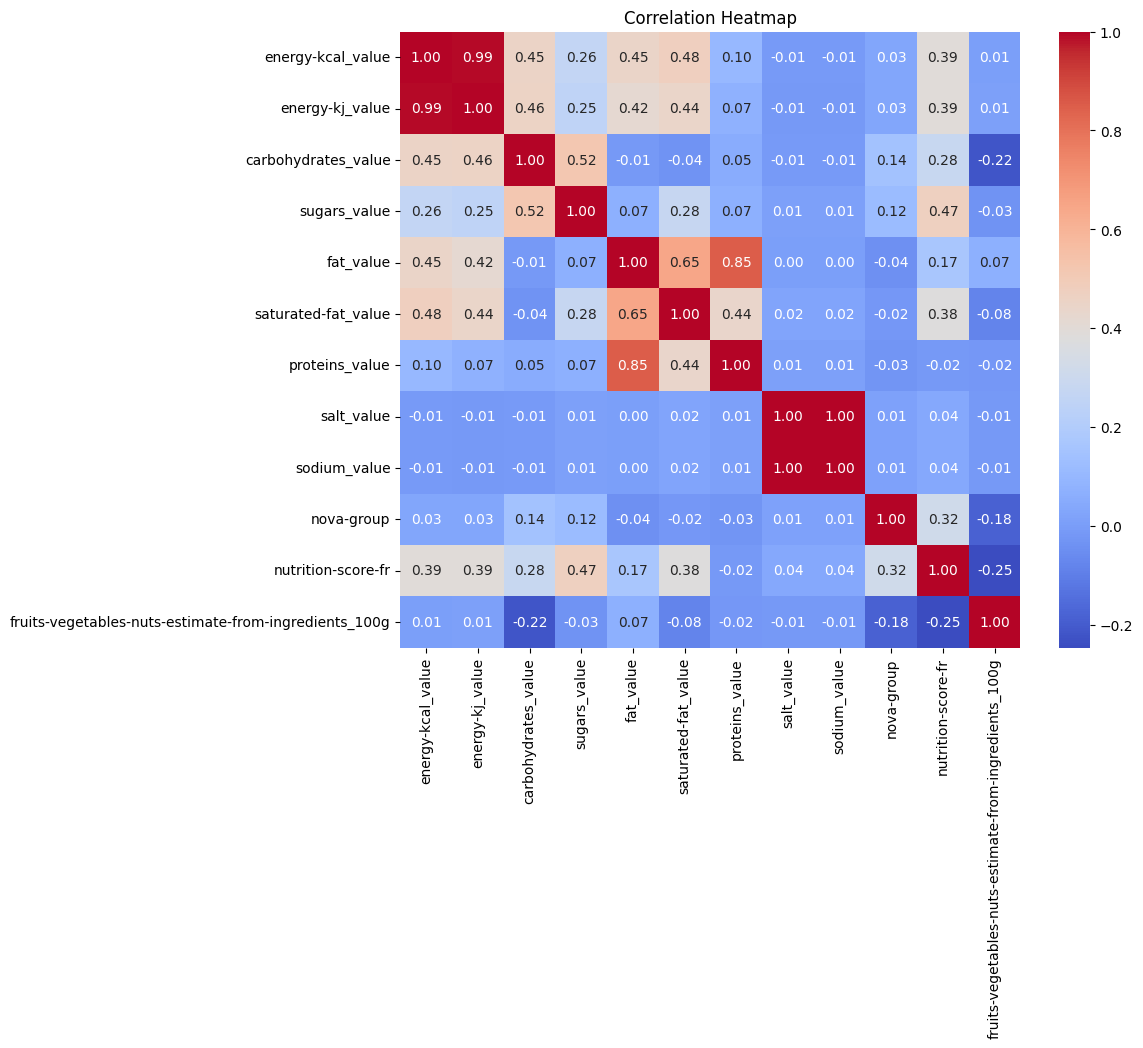

In [6]:
correlation_matrix=df.iloc[:,3:-4]
correlation_matrix=correlation_matrix.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap='coolwarm')
plt.title('Correlation Heatmap')

In [7]:
numeric_cols = [
    'energy-kcal_value', 'sugars_value', 'carbohydrates_value',
    'fat_value', 'proteins_value', 'saturated-fat_value',
    'salt_value', 'sodium_value', 'sugar_to_carb_ratio'
]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
energy-kcal_value,10845.0,275.486794,204.223368,0.0,92.00000,243.000000,434.000000,947.0
sugars_value,10845.0,11.427678,19.372091,0.0,1.00000,4.100000,13.000000,895.0
carbohydrates_value,10845.0,28.399967,27.041380,0.0,4.80000,15.600000,55.000000,130.3
fat_value,10845.0,14.764391,38.236812,0.0,1.30000,6.200000,21.000000,3400.0
proteins_value,10845.0,7.218908,30.098055,0.0,1.46800,5.600000,9.300000,3000.0
saturated-fat_value,10845.0,5.016057,11.055763,0.0,0.30000,1.400000,5.700000,595.0
salt_value,10845.0,9.082823,186.608425,0.0,0.05000,0.355000,1.000000,12500.0
sodium_value,10845.0,3.633129,74.643370,0.0,0.02000,0.142000,0.400000,5000.0
sugar_to_carb_ratio,10227.0,0.526904,0.639749,0.0,0.10241,0.481013,0.925532,38.0


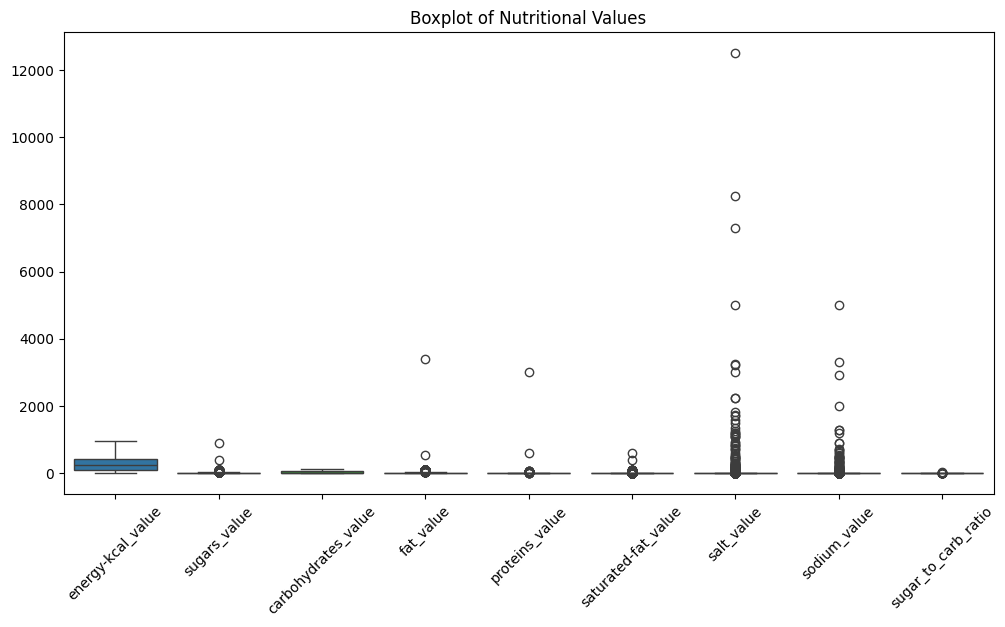

In [8]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Nutritional Values")
plt.show()


In [42]:
def get_outliers(df, cols):
    outlier_dict = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # rows that are outliers for this column
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        
        outlier_dict[col] = outliers
    return outlier_dict

# usage
outlier_rows = get_outliers(df, numeric_cols)

# Example: check outliers for 'sugars_value'
outlier_rows['sugar_to_carb_ratio'].shape


(23, 19)

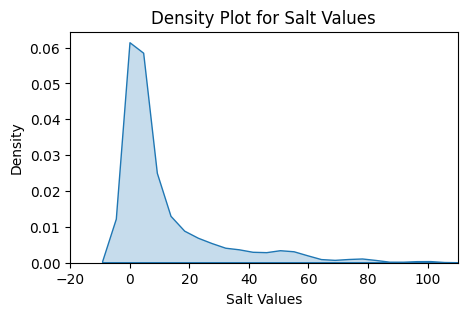

In [9]:
# Density Plot for MPG 
plt.figure(figsize = (5, 3))
sns.kdeplot(df['sugars_value'], fill = True)
plt.xlabel('Salt Values')
plt.ylabel('Density')
plt.title('Density Plot for Salt Values')
plt.xlim(-20,110)
plt.show()

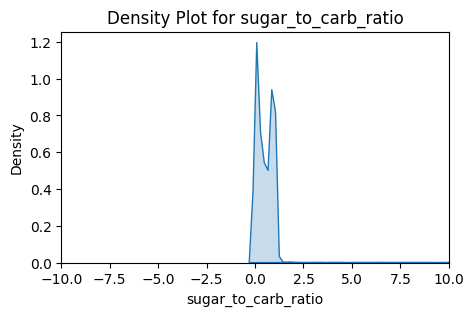

In [41]:
# Density Plot for MPG 
plt.figure(figsize = (5, 3))
sns.kdeplot(df['sugar_to_carb_ratio'], fill = True)
plt.xlabel('sugar_to_carb_ratio')
plt.ylabel('Density')
plt.title('Density Plot for sugar_to_carb_ratio')
plt.xlim(-10,10)
plt.show()

In [ ]:
"""
Salt and Sodium Values has 584 outliers.
energy-kcal_value has 4 outliers.
Salt values above 30-40 range can be considered as oultiers
"""

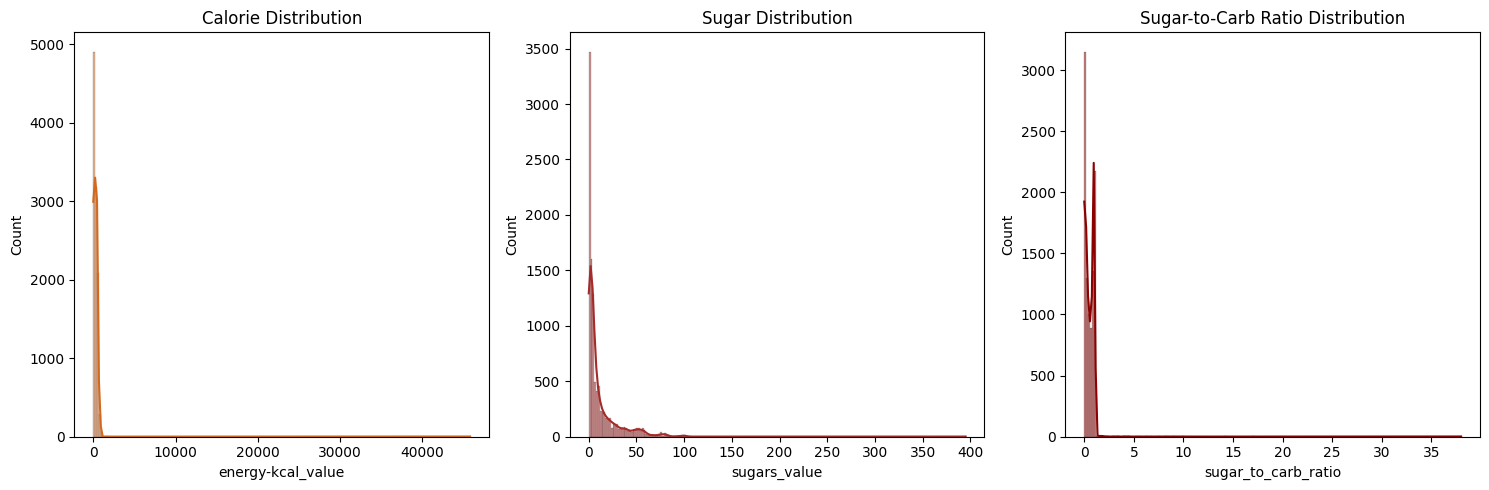

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.histplot(df['energy-kcal_value'], kde=True, ax=axes[0], color='chocolate')
sns.histplot(df['sugars_value'], kde=True, ax=axes[1], color='brown')
sns.histplot(df['sugar_to_carb_ratio'], kde=True, ax=axes[2], color='darkred')
axes[0].set_title("Calorie Distribution")
axes[1].set_title("Sugar Distribution")
axes[2].set_title("Sugar-to-Carb Ratio Distribution")
plt.tight_layout()
plt.show()


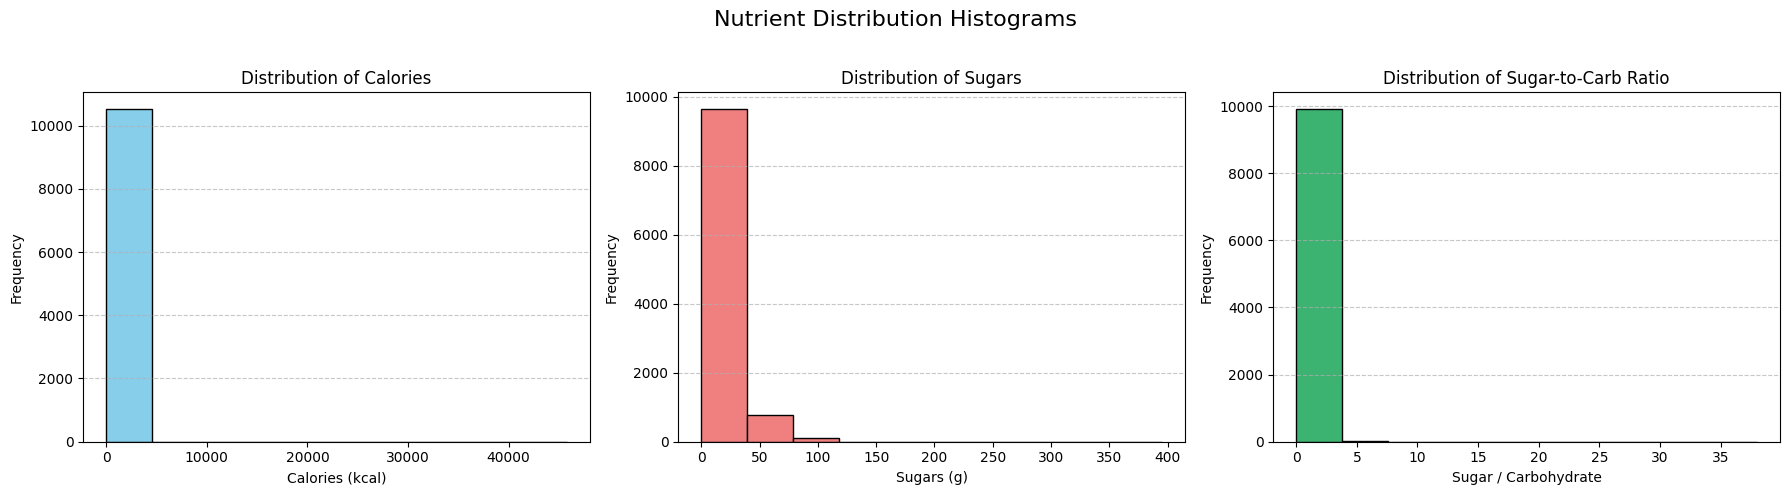

In [71]:
# Set up the plot with multiple subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Nutrient Distribution Histograms', fontsize=16)

# Histogram for Calories
axs[0].hist(df['energy-kcal_value'], bins=10, edgecolor='black', color='skyblue')
axs[0].set_title('Distribution of Calories')
axs[0].set_xlabel('Calories (kcal)')
axs[0].set_ylabel('Frequency')
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram for Sugars
axs[1].hist(df['sugars_value'], bins=10, edgecolor='black', color='lightcoral')
axs[1].set_title('Distribution of Sugars')
axs[1].set_xlabel('Sugars (g)')
axs[1].set_ylabel('Frequency')
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram for Sugar-to-Carb Ratio
axs[2].hist(df['sugar_to_carb_ratio'], bins=10, edgecolor='black', color='mediumseagreen')
axs[2].set_title('Distribution of Sugar-to-Carb Ratio')
axs[2].set_xlabel('Sugar / Carbohydrate')
axs[2].set_ylabel('Frequency')
axs[2].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent titles from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the plot
plt.show()


# Number of Products per Calorie Category

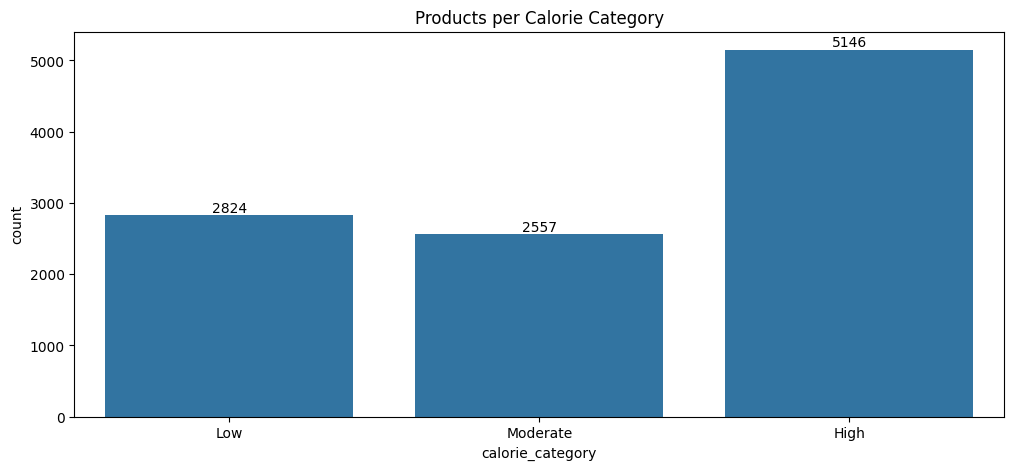

In [ ]:
plt.figure(figsize=(12,5))
ax = sns.countplot(data=df, x='calorie_category')
plt.title("Products per Calorie Category")

# Add counts on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 50,
            int(height), ha="center", fontsize=10)

plt.show()


C:\Users\kevin\AppData\Local\Temp\ipykernel_6216\3778202167.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df, x='sugar_category', palette='magma')


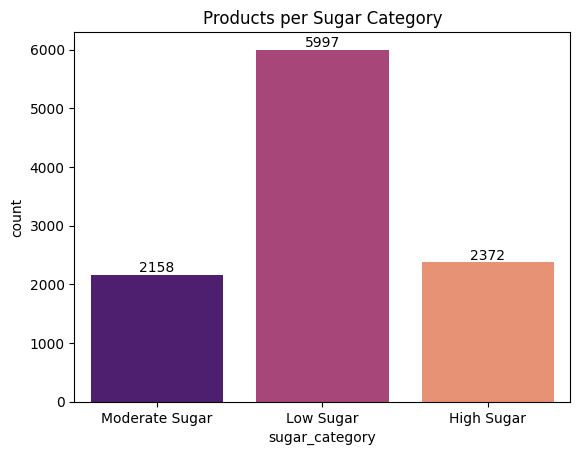

In [55]:
ax=sns.countplot(data=df, x='sugar_category', palette='magma')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 50,
            int(height), ha="center", fontsize=10)

plt.title("Products per Sugar Category")
plt.show()

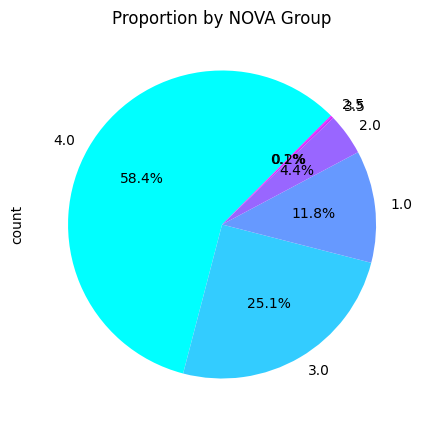

In [58]:
plt.figure(figsize=(8,5))
df['nova-group'].value_counts().plot.pie(autopct='%1.1f%%', startangle=45, cmap='cool')
plt.title("Proportion by NOVA Group")
# plt.ylabel("")
plt.show()

# # Ultra vs Non-ultra
# df['is_ultra_processed'].value_counts().plot(kind='bar', color=['green','red'])
# plt.title("Ultra-Processed vs Non-Ultra Products")
# plt.show()


In [63]:
percentage_results = df['nova-group'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'
percentage_results

nova-group
4.0    58.4%
3.0    25.1%
1.0    11.8%
2.0     4.4%
3.5     0.2%
2.5     0.1%
Name: proportion, dtype: object

In [ ]:
"""
Group 1 includes unprocessed or minimally processed foods (like fresh fruit),
Group 2 consists of processed culinary ingredients (like oils and salt), 
Group 3 comprises processed foods (like canned vegetables), and 
Group 4 contains ultra-processed foods (like soft drinks). 
"""

"""
58.4 % are of ultra-processed foods meaning very bad for health
Only 11.8% of the foods are minimally processed foods
"""

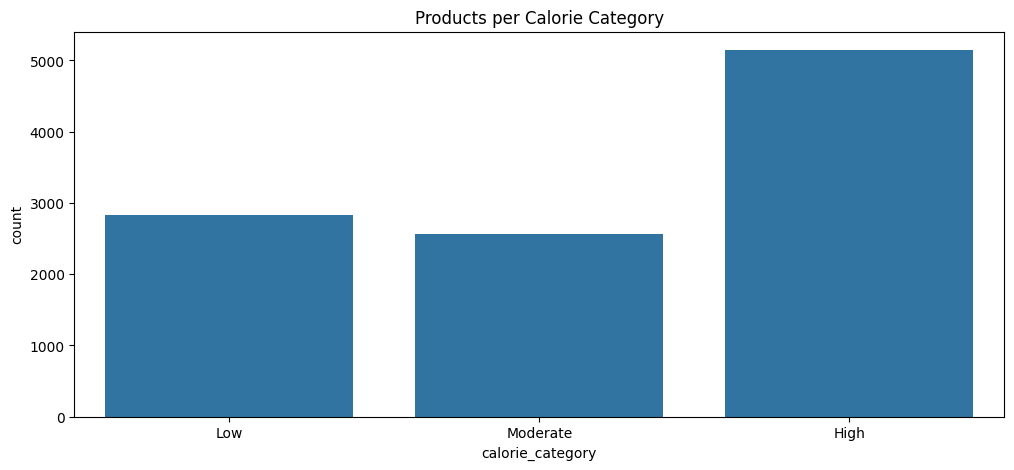

C:\Users\kevin\AppData\Local\Temp\ipykernel_6216\1953804476.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sugar_category', palette='magma')


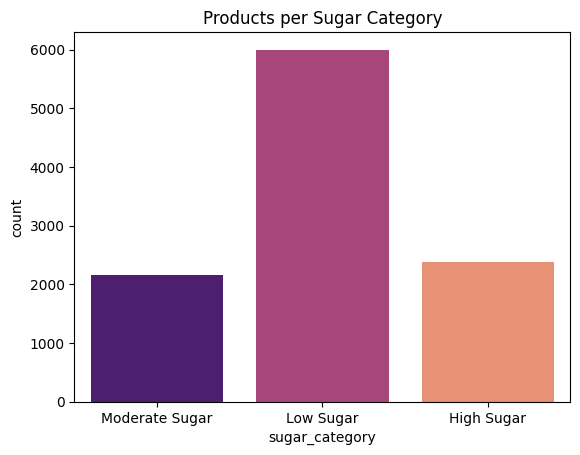

In [73]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='calorie_category')
plt.title("Products per Calorie Category")
plt.show()

sns.countplot(data=df, x='sugar_category', palette='magma')
plt.title("Products per Sugar Category")
plt.show()


C:\Users\kevin\AppData\Local\Temp\ipykernel_6216\486362518.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x='energy-kcal_value',y='sugars_value',palette='magma')


Text(0.5, 1.0, 'Scatter for Sugar value and Calorie')

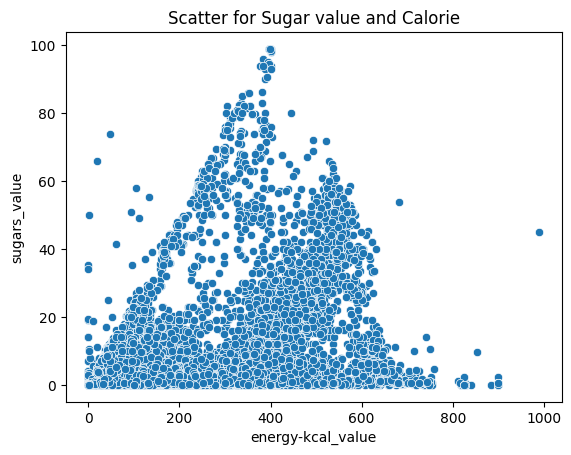

In [ ]:
df = df[(df['energy-kcal_value'] < 1000) & (df['sugars_value'] < 100)]
sns.scatterplot(data=df,x='energy-kcal_value',y='sugars_value',palette='magma')
plt.title("Scatter for Sugar value and Calorie")

C:\Users\kevin\AppData\Local\Temp\ipykernel_6216\143756515.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['health_zone'] = df.apply(categorize_zone, axis=1)


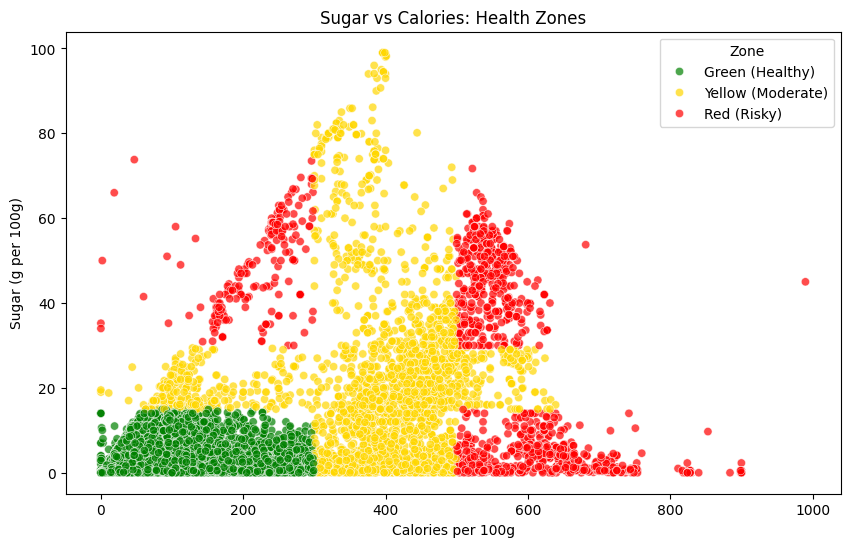

In [83]:
# Define zones
def categorize_zone(row):
    if row['sugars_value'] < 15 and row['energy-kcal_value'] < 300:
        return 'Green (Healthy)'
    elif (15 <= row['sugars_value'] < 30) or (300 <= row['energy-kcal_value'] < 500):
        return 'Yellow (Moderate)'
    else:
        return 'Red (Risky)'

# Apply
df['health_zone'] = df.apply(categorize_zone, axis=1)

# Plot
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='energy-kcal_value',
    y='sugars_value',
    hue='health_zone',
    palette={'Green (Healthy)':'green', 'Yellow (Moderate)':'gold', 'Red (Risky)':'red'},
    alpha=0.7
)
plt.title("Sugar vs Calories: Health Zones")
plt.xlabel("Calories per 100g")
plt.ylabel("Sugar (g per 100g)")
plt.legend(title="Zone")
plt.show()

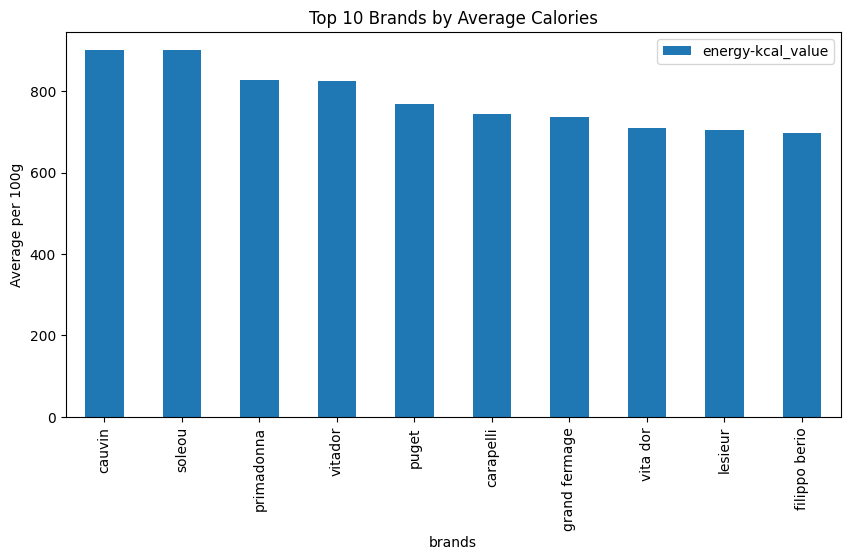

In [98]:
top_brands = df.groupby('brands').filter(lambda x:len(x)>=3).groupby('brands')[['energy-kcal_value']].mean().sort_values('energy-kcal_value', ascending=False).head(10)

top_brands.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Brands by Average Calories")
plt.ylabel("Average per 100g")
plt.show()


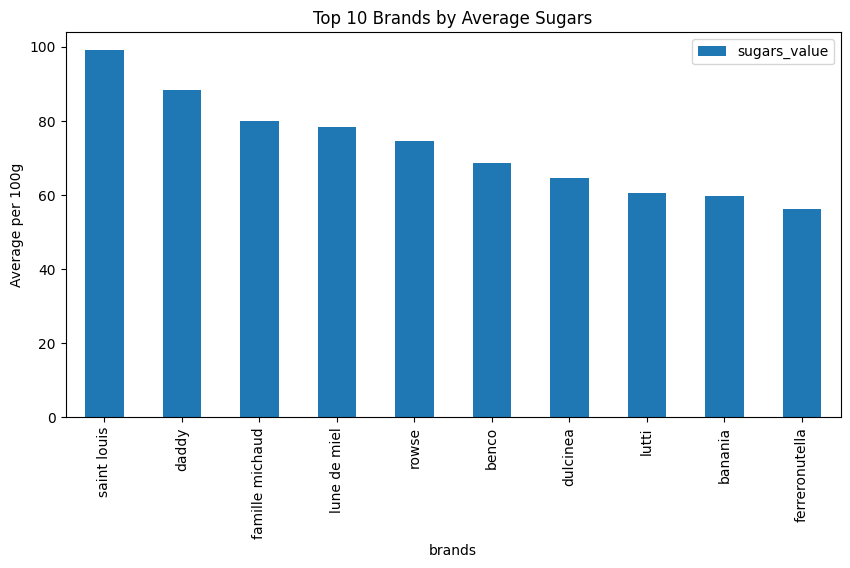

In [97]:
top_brands = df.groupby('brands').filter(lambda x:len(x)>=3).groupby('brands')[['sugars_value']].mean().sort_values('sugars_value', ascending=False).head(10)

top_brands.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Brands by Average Sugars")
plt.ylabel("Average per 100g")
plt.show()


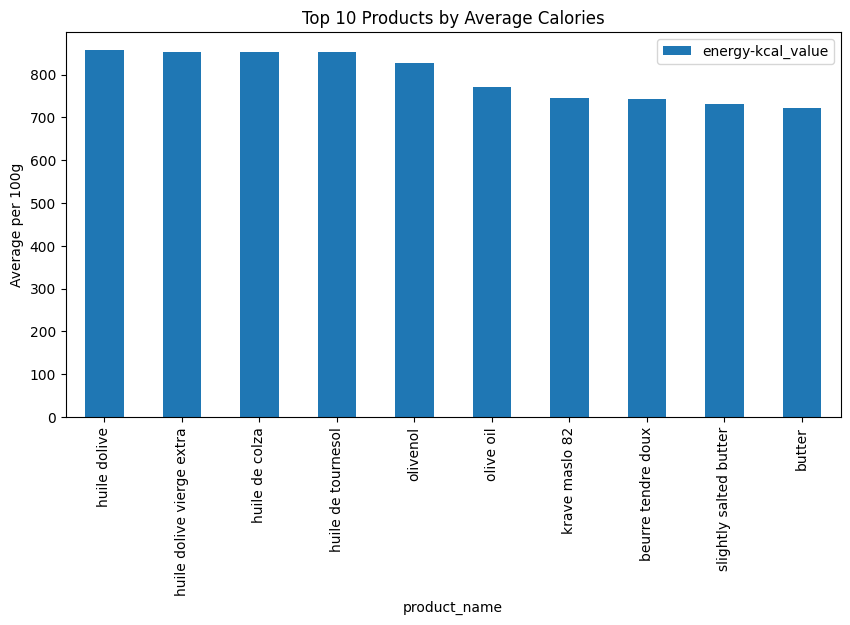

In [95]:
top_brands = df.groupby('product_name').filter(lambda x: len(x) >= 3).groupby('product_name')[['energy-kcal_value']].mean().sort_values('energy-kcal_value', ascending=False).head(10)

top_brands.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products by Average Calories")
plt.ylabel("Average per 100g")
plt.show()


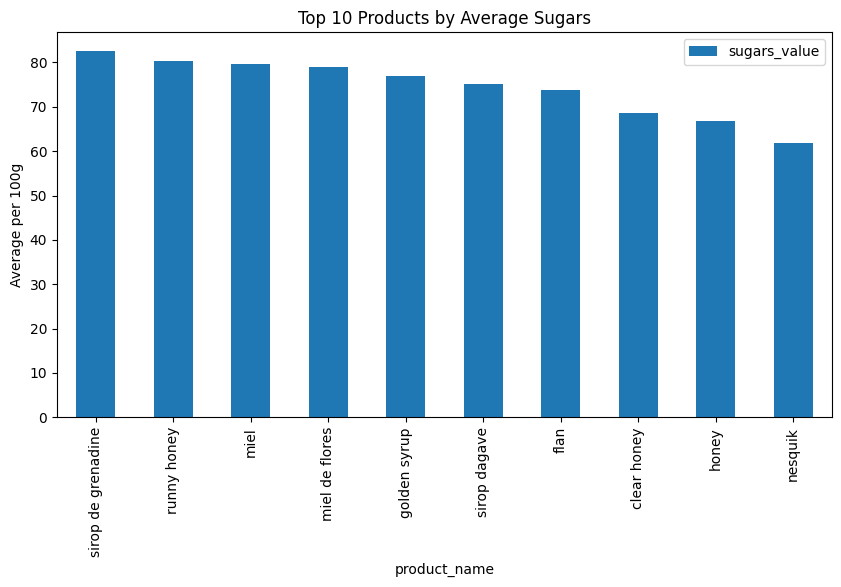

In [94]:
top_brands = df.groupby('product_name').filter(lambda x: len(x) >= 3).groupby('product_name')[['sugars_value']].mean().sort_values('sugars_value', ascending=False).head(10)

top_brands.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products by Average Sugars")
plt.ylabel("Average per 100g")
plt.show()


In [92]:
result = (
    df.groupby('product_name')
    .filter(lambda x: len(x) >= 3)   # keep only groups with 3+ rows
    .groupby('product_name')[['sugars_value']]
    .mean()
    .sort_values('sugars_value', ascending=False)
)

print(result)


                                 sugars_value
product_name                                 
sirop de grenadine                  82.666667
runny honey                         80.360000
miel                                79.766667
miel de flores                      79.000000
golden syrup                        76.900000
...                                       ...
stevia                               0.000000
thon entier au naturel albacore      0.000000
thon entier au naturel               0.000000
agua mineral natural                 0.000000
acqua minerale                       0.000000

[299 rows x 1 columns]


In [91]:
df.groupby('product_name')[['sugars_value']].count().sort_values('sugars_value', ascending=False)

,sugars_value
product_name,
tomato ketchup,34
crunchy peanut butter,19
mayonnaise,18
eau minerale naturelle,18
nutella,17
...,...
yoyos raspberry multipack 5 x,1
yoyos strawberry multipack 5 x,1
yumyum beef,1


In [103]:
high_sugar = df[df['sugar_category'] == 'High Sugar']
high_calorie = df[df['calorie_category'] == 'High']
ultra_processed = df[df['is_ultra_processed'] == 'Yes']

print(f"High sugar products: {len(high_sugar)}")
print(f"High calorie products: {len(high_calorie)}")
print(f"Ultra processed products: {len(ultra_processed)}")


High sugar products: 2351
High calorie products: 5125
Ultra processed products: 6150


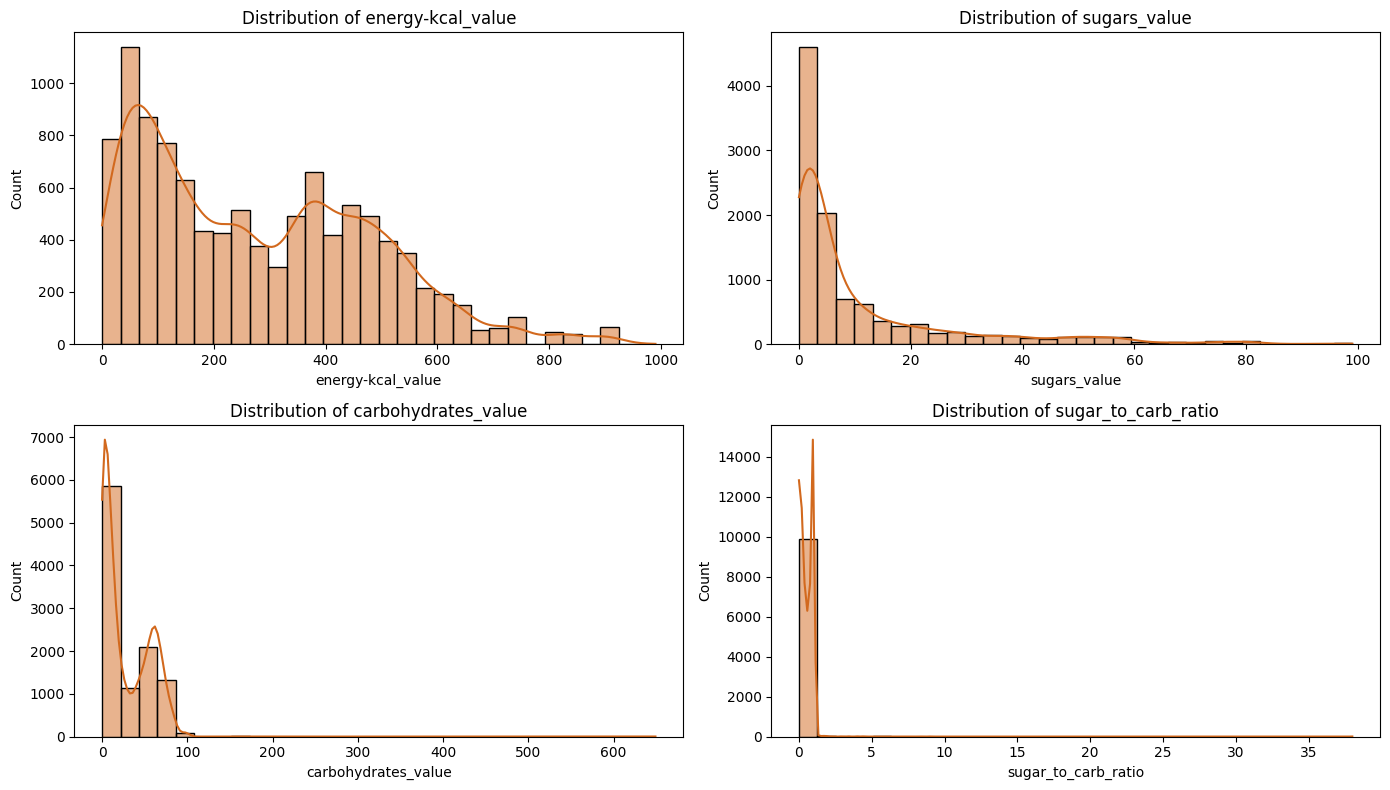

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

key_vars = ['energy-kcal_value', 'sugars_value', 'carbohydrates_value', 'sugar_to_carb_ratio']

plt.figure(figsize=(14, 8))
for i, col in enumerate(key_vars, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='chocolate', bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


C:\Users\kevin\AppData\Local\Temp\ipykernel_6216\3688077679.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='calorie_category', palette='Reds')
C:\Users\kevin\AppData\Local\Temp\ipykernel_6216\3688077679.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sugar_category', palette='Oranges')
C:\Users\kevin\AppData\Local\Temp\ipykernel_6216\3688077679.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='nova-group', palette='coolwarm')


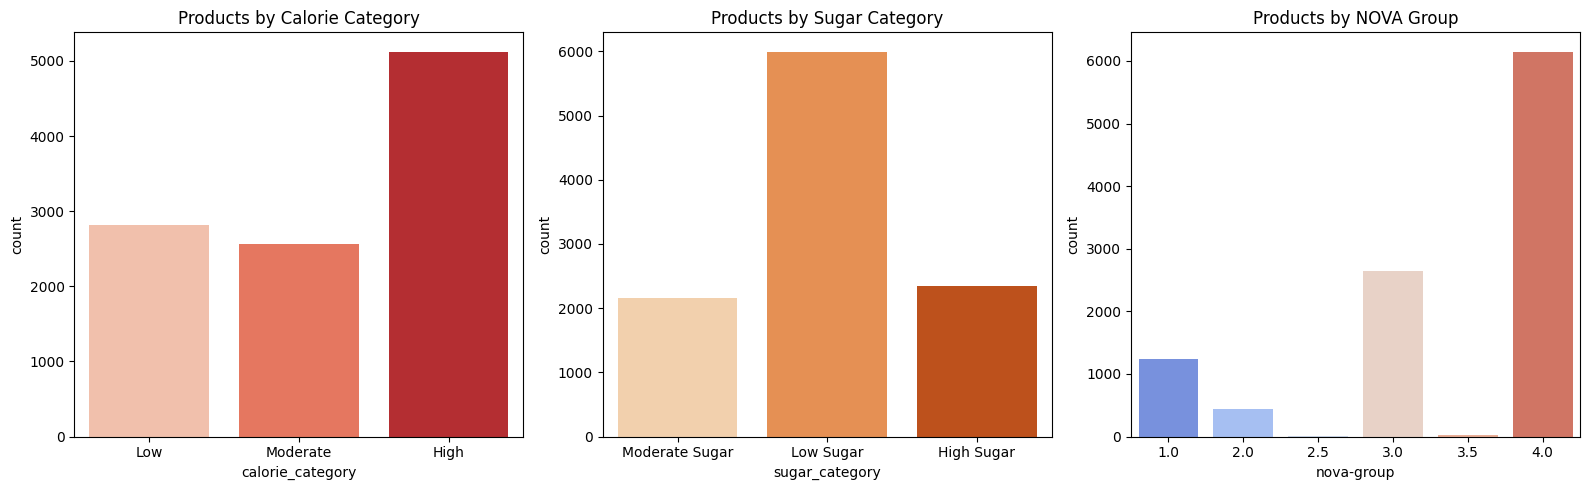

In [105]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='calorie_category', palette='Reds')
plt.title('Products by Calorie Category')

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='sugar_category', palette='Oranges')
plt.title('Products by Sugar Category')

plt.subplot(1, 3, 3)
sns.countplot(data=df, x='nova-group', palette='coolwarm')
plt.title('Products by NOVA Group')

plt.tight_layout()
plt.show()


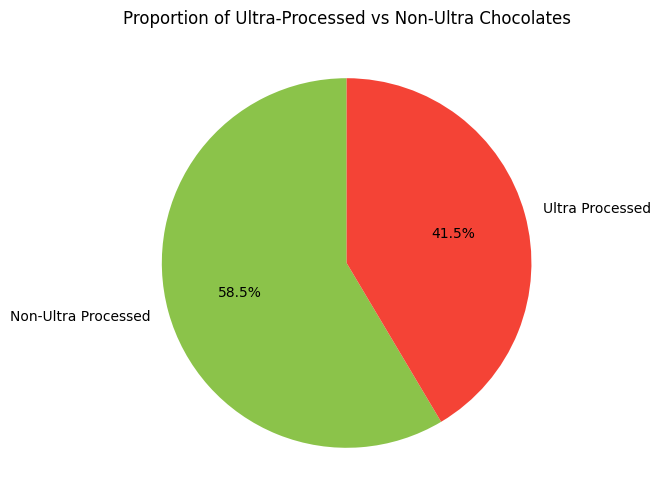

In [106]:
plt.figure(figsize=(6,6))
df['is_ultra_processed'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    startangle=90, 
    labels=['Non-Ultra Processed', 'Ultra Processed'],
    colors=['#8BC34A', '#F44336']
)
plt.title("Proportion of Ultra-Processed vs Non-Ultra Chocolates")
plt.ylabel("")
plt.show()


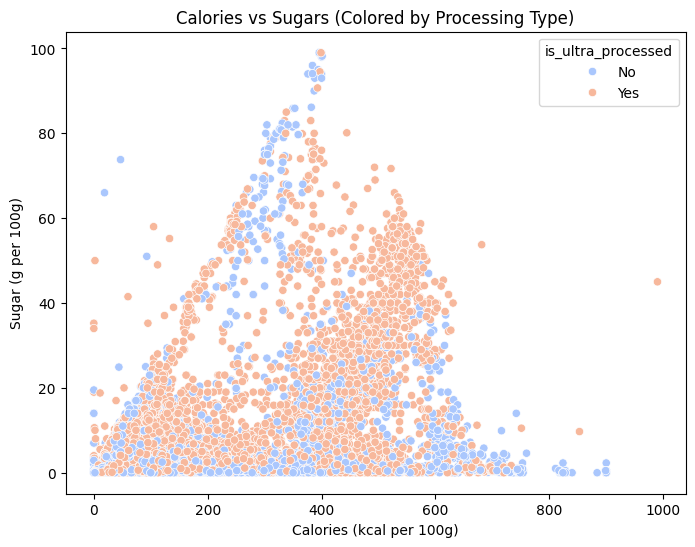

In [107]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='energy-kcal_value', y='sugars_value', hue='is_ultra_processed', palette='coolwarm')
plt.title("Calories vs Sugars (Colored by Processing Type)")
plt.xlabel("Calories (kcal per 100g)")
plt.ylabel("Sugar (g per 100g)")
plt.show()


C:\Users\kevin\AppData\Local\Temp\ipykernel_6216\2308012799.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='nova-group', y='energy-kcal_value', palette='mako')


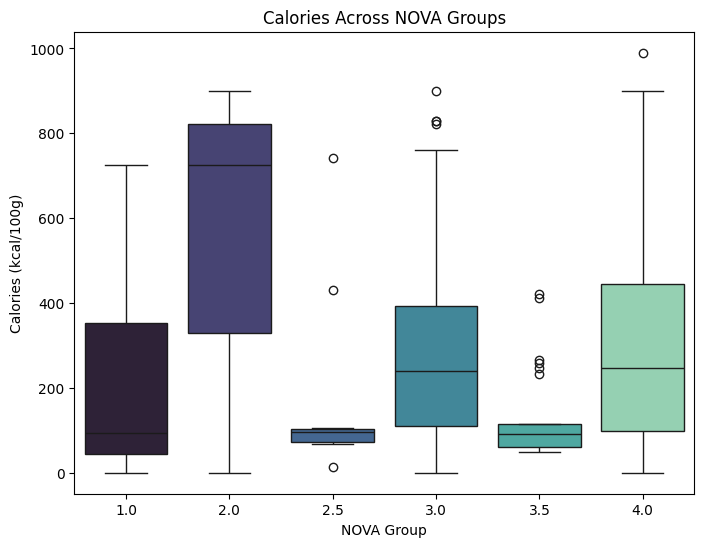

In [108]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='nova-group', y='energy-kcal_value', palette='mako')
plt.title("Calories Across NOVA Groups")
plt.xlabel("NOVA Group")
plt.ylabel("Calories (kcal/100g)")
plt.show()
